In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
base_dir = r"C:\Users\HP ELITE BOOK\Documents\Project Dave\Face Mask detection\data"
train_dir = base_dir  # data already split in with_mask / without_mask folders

# Image parameters
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32

# Data augmentation and normalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,  # 20% validation split
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Train generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

# Validation generator
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 15477 images belonging to 2 classes.
Found 3868 images belonging to 2 classes.


In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Load MobileNetV2 base model, excluding top layers
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze base model
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)  # flatten feature maps
x = Dropout(0.3)(x)               # prevent overfitting
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(1, activation='sigmoid')(x)  # binary output

# Create final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Show model summary
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
# Number of epochs
EPOCHS = 10  # you can increase later

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    epochs=EPOCHS
)

Epoch 1/10
169/483 ━━━━━━━━━━━━━━━━━━━━ 6:59 1s/step - accuracy: 0.7858 - loss: 0.4315

C:\Users\HP ELITE BOOK\AppData\Roaming\Python\Python311\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


483/483 ━━━━━━━━━━━━━━━━━━━━ 790s 2s/step - accuracy: 0.9231 - loss: 0.1872 - val_accuracy: 0.9661 - val_loss: 0.0998
Epoch 2/10
  1/483 ━━━━━━━━━━━━━━━━━━━━ 5:21 667ms/step - accuracy: 1.0000 - loss: 0.0363

C:\Users\HP ELITE BOOK\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


483/483 ━━━━━━━━━━━━━━━━━━━━ 108s 222ms/step - accuracy: 1.0000 - loss: 0.0363 - val_accuracy: 0.9612 - val_loss: 0.1062
Epoch 3/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 527s 1s/step - accuracy: 0.9642 - loss: 0.0982 - val_accuracy: 0.9656 - val_loss: 0.0916
Epoch 4/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 106s 220ms/step - accuracy: 0.9688 - loss: 0.0364 - val_accuracy: 0.9651 - val_loss: 0.0932
Epoch 5/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 513s 1s/step - accuracy: 0.9703 - loss: 0.0819 - val_accuracy: 0.9682 - val_loss: 0.0911
Epoch 6/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 103s 212ms/step - accuracy: 1.0000 - loss: 0.0380 - val_accuracy: 0.9641 - val_loss: 0.1031
Epoch 7/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 1580s 3s/step - accuracy: 0.9725 - loss: 0.0724 - val_accuracy: 0.9737 - val_loss: 0.0815
Epoch 8/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 114s 235ms/step - accuracy: 1.0000 - loss: 0.0109 - val_accuracy: 0.9734 - val_loss: 0.0748
Epoch 9/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 541s 1s/step - accuracy: 0.9764 - loss: 0.0639 - val_ac

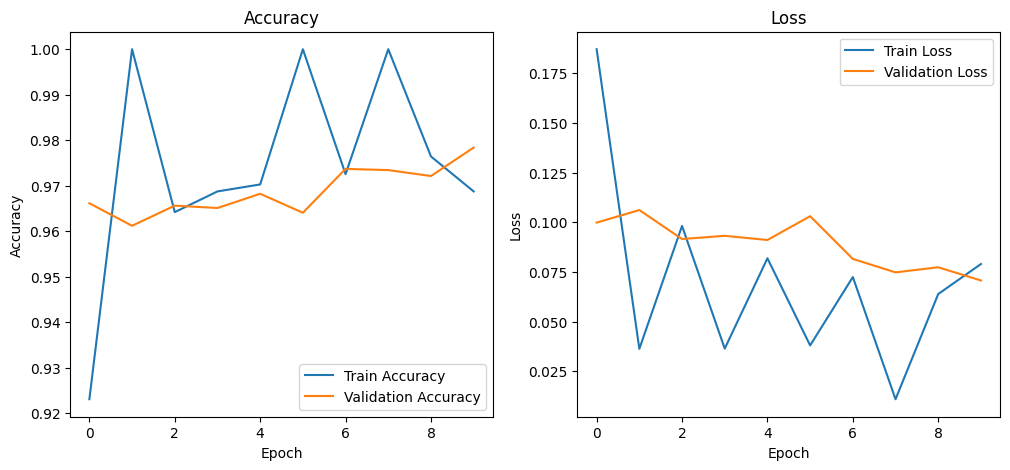

In [6]:
# Plot training & validation accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [7]:
import numpy as np

# Get true labels
y_true = val_generator.classes

# Predict probabilities
y_pred_prob = model.predict(val_generator)

# Convert probabilities to class labels
y_pred = (y_pred_prob > 0.5).astype("int32").ravel()

121/121 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step


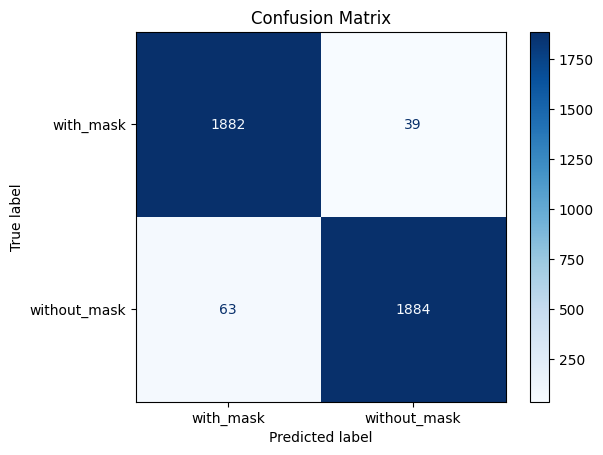

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=val_generator.class_indices.keys()
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


In [13]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=val_generator.class_indices.keys()
))

              precision    recall  f1-score   support

   with_mask       0.97      0.98      0.97      1921
without_mask       0.98      0.97      0.97      1947

    accuracy                           0.97      3868
   macro avg       0.97      0.97      0.97      3868
weighted avg       0.97      0.97      0.97      3868

